# Smart Aid Finder
### A data-driven system to connect donors with aid recipients
**Author:** Keziah Ndanu Masai  
**Course:** Bachelor of Computer Science — Riara University  
**Date:** 2025

---

## Project Goal

Create a smart aid-matching system to connect people who need help with those who can offer it. The system supports:

- User registration (Donors & Receivers)
- Donating and requesting items/services
- Matching based on category & urgency
- Location-based matching to speed up connecting users
- Match history with undo functionality
- Data export to JSON and CSV
- **Data analysis and visualisation of aid patterns**


---
## 1. User Registration System

Defines a `UserRegistry` class using a Python dictionary (hash map) to store user data.

**Key features:**
- `register_user()` — validates input, rejects duplicates, accepts only `donor` or `receiver` types
- `get_user()` — safely retrieves a user by their unique ID
- Timestamps added at registration using ISO format for traceability


In [5]:
from datetime import datetime  # Used to add timestamps when users are registered.

class UserRegistry:  # Groups user registration and lookup logic inside an OOP structure.
    def __init__(self):  # Constructor, called when the class is created.
        self.users = {}  # Instance variable — empty dictionary to store user data.

    def register_user(self, user_id, name, user_type, location):  # Method for new user registration.
        if user_id in self.users:  # Checks if the user already exists using the key user_id.
            return {"success": False, "message": f"User ID '{user_id}' already exists."}

        if user_type not in {"donor", "receiver"}:  # Validates that user type is only "donor" or "receiver".
            return {"success": False, "message": "User type must be 'donor' or 'receiver'."}

        self.users[user_id] = {
            "name": name,
            "type": user_type,
            "location": location,
            "registered_at": datetime.now().isoformat()  # ISO format for traceability.
        }
        return {"success": True, "message": f"User '{name}' registered successfully."}

    def get_user(self, user_id):  # Retrieves user by ID.
        user = self.users.get(user_id)  # Uses dict.get() to safely retrieve the user.
        if not user:
            return {"success": False, "message": "User not found."}
        return {"success": True, "user": user}

# Example Usage
user_registry = UserRegistry()
print(user_registry.register_user("U001", "Keizy", "receiver", "Nairobi"))
print(user_registry.register_user("U002", "John", "donor", "Nairobi"))


{'success': True, 'message': "User 'Keizy' registered successfully."}
{'success': True, 'message': "User 'John' registered successfully."}


In [7]:
# Helper function to extract user details by ID
def get_user(user_id):
    response = user_registry.get_user(user_id)
    if response["success"]:
        return response["user"]
    else:
        return {"name": "Unknown"}  # Default fallback if user not found


---
## 2. Aid System — Donations & Requests

The `AidSystem` class manages donations from donors and aid requests from receivers.

**Key features:**
- `add_donation()` — validates required fields and stores donation with a timestamp
- `add_request()` — stores aid requests with urgency level (1 = most urgent)
- `get_all_requests()` — returns requests sorted by urgency using a lambda function


In [10]:
from datetime import datetime

class AidSystem:
    def __init__(self):
        self.donations = []  # A list for donations.
        self.requests  = []  # A list for requests.

    def add_donation(self, user_id, item, category, location):  # Method for new donations.
        donation = {
            "user_id":   user_id,
            "item":      item,
            "category":  category.lower(),
            "location":  location.lower(),
            "timestamp": datetime.now().isoformat()
        }
        self.donations.append(donation)  # Add donation to the donation list.
        return {"success": True, "donation": donation}

    def add_request(self, user_id, need, category, urgency, location):  # Handle aid request.
        if not all([user_id, need, category, urgency is not None]):
            return {"success": False, "message": "Missing request details."}

        request = {
            "user_id":   user_id,
            "need":      need,
            "category":  category.lower(),
            "urgency":   urgency,
            "location":  location.lower(),
            "timestamp": datetime.now().isoformat()
        }
        self.requests.append(request)  # Add request to the list of requests.
        return {"success": True, "request": request}

    def get_all_donations(self):  # Returns the full donations list.
        return self.donations

    def get_all_requests(self):  # Returns requests sorted by urgency (most urgent first).
        return sorted(self.requests, key=lambda r: r["urgency"])

# Example Usage
aid_system = AidSystem()
print(aid_system.add_donation("U002", "Food Pack", "Food", "Nairobi"))
print(aid_system.add_request("U001", "Lunch Meal", "Food", urgency=1, location="Nairobi"))
print("All Donations:", aid_system.get_all_donations())
print("All Requests (sorted by urgency):", aid_system.get_all_requests())


{'success': True, 'donation': {'user_id': 'U002', 'item': 'Food Pack', 'category': 'food', 'location': 'nairobi', 'timestamp': '2026-05-11T05:03:38.799720'}}
{'success': True, 'request': {'user_id': 'U001', 'need': 'Lunch Meal', 'category': 'food', 'urgency': 1, 'location': 'nairobi', 'timestamp': '2026-05-11T05:03:38.800719'}}
All Donations: [{'user_id': 'U002', 'item': 'Food Pack', 'category': 'food', 'location': 'nairobi', 'timestamp': '2026-05-11T05:03:38.799720'}]
All Requests (sorted by urgency): [{'user_id': 'U001', 'need': 'Lunch Meal', 'category': 'food', 'urgency': 1, 'location': 'nairobi', 'timestamp': '2026-05-11T05:03:38.800719'}]


---
## 3. Matching Algorithm

Matches aid requests to available donations based on **category**, **location**, and **urgency**.

**Key features:**
- Sorts requests by urgency so the most critical needs are fulfilled first
- Ensures each donation is only used once (tracked via `used_donations` set)
- Returns both matched pairs and unmatched requests


In [13]:
class AidSystem:
    def __init__(self):
        self.donations = []
        self.requests  = []

    def add_donation(self, user_id, item, category, location):
        donation = {
            "user_id":   user_id,
            "item":      item,
            "category":  category.lower(),
            "location":  location.lower(),
            "timestamp": datetime.now().isoformat()
        }
        self.donations.append(donation)
        return {"success": True, "donation": donation}

    def add_request(self, user_id, need, category, urgency, location):
        request = {
            "user_id":  user_id,
            "need":     need,
            "category": category.lower(),
            "urgency":  urgency,
            "location": location.lower(),
            "timestamp": datetime.now().isoformat()
        }
        self.requests.append(request)
        return {"success": True, "request": request}

    def match_requests(self):
        matches            = []   # List of matched (request, donation) pairs.
        unmatched_requests = []   # Requests that couldn't be matched.
        used_donations     = set()  # Tracks matched donations by index.

        sorted_requests = sorted(self.requests, key=lambda r: r["urgency"])  # Most urgent first.

        for request in sorted_requests:
            matched = False
            for i, donation in enumerate(self.donations):
                if i in used_donations:
                    continue  # Skip already-matched donations.

                # Match only if category AND location are the same.
                if (request["category"] == donation["category"] and
                        request["location"] == donation["location"]):
                    matches.append((request, donation))
                    used_donations.add(i)  # Mark donation as used.
                    matched = True
                    break  # Move to next request.

            if not matched:
                unmatched_requests.append(request)

        return matches, unmatched_requests

# Example Usage
aid_system = AidSystem()
aid_system.add_donation("U002", "Food Pack", "Food", "Nairobi")
aid_system.add_request("U001", "Lunch Meal", "Food", urgency=1, location="Nairobi")

matches, unmatched = aid_system.match_requests()

for req, don in matches:
    print(f"{get_user(req['user_id'])['name']} matched with "
          f"{get_user(don['user_id'])['name']} for {don['item']}")

if unmatched:
    print("\nUnmatched Requests:")
    for req in unmatched:
        print(req)


Keizy matched with John for Food Pack


---
## 4. Match History (LIFO Stack)

Uses a **stack (Last In, First Out)** data structure to track match history.

**Key features:**
- `save()` — pushes a matched pair onto the stack
- `undo_last()` — pops the most recent match (simulates Ctrl+Z)
- `show_history()` — prints all saved matches in reverse order
- `export_to_json()` / `export_to_csv()` — exports match history for persistent storage, auditing, and reporting


In [16]:
import json
import csv

class MatchHistory:
    def __init__(self):
        self.stack = []  # Stores (request, donation) tuples — internal list used as a stack.

    def save(self, request, donation):
        """Save a matched pair to the history stack."""
        self.stack.append((request, donation))
        print(f"[Saved] Match: {request['need']} ← {donation['item']}")

    def undo_last(self):
        """Undo the last match (simulates Ctrl+Z). Returns the undone pair or None."""
        if self.stack:
            request, donation = self.stack.pop()
            print(f"[Undo] Removed match: {request['need']} ← {donation['item']}")
            return request, donation
        else:
            print("[Undo] No matches to undo.")
            return None

    def show_history(self):
        """Print all past matches in reverse order."""
        if not self.stack:
            print("Match history is empty.")
            return
        print("Match History:")
        for i, (req, don) in enumerate(reversed(self.stack), 1):
            print(f"  {i}. {req['need']} ← {don['item']} (Location: {req['location'].title()})")

    def export_to_json(self, filename="match_history.json"):
        """Export match history to a JSON file."""
        data = [
            {
                "requester_id": req["user_id"],
                "donor_id":     don["user_id"],
                "need":         req["need"],
                "item":         don["item"],
                "category":     req["category"],
                "location":     req["location"],
                "urgency":      req["urgency"],
                "matched_at":   don["timestamp"]
            }
            for req, don in self.stack
        ]
        with open(filename, "w") as f:
            json.dump(data, f, indent=2)
        print(f"Match history exported to {filename}")

    def export_to_csv(self, filename="match_history.csv"):
        """Export match history to a CSV file."""
        if not self.stack:
            print("No matches to export.")
            return
        headers = ["requester_id", "donor_id", "need", "item",
                   "category", "location", "urgency", "matched_at"]
        with open(filename, mode="w", newline="") as file:
            writer = csv.DictWriter(file, fieldnames=headers)
            writer.writeheader()
            for req, don in self.stack:
                writer.writerow({
                    "requester_id": req["user_id"],
                    "donor_id":     don["user_id"],
                    "need":         req["need"],
                    "item":         don["item"],
                    "category":     req["category"],
                    "location":     req["location"],
                    "urgency":      req["urgency"],
                    "matched_at":   don["timestamp"]
                })
        print(f"Match history exported to {filename}")

# Example Usage
history = MatchHistory()

for req, don in matches:
    history.save(req, don)

history.undo_last()
history.show_history()

# Export
history.export_to_json("matches.json")
history.export_to_csv("matches.csv")


[Saved] Match: Lunch Meal ← Food Pack
[Undo] Removed match: Lunch Meal ← Food Pack
Match history is empty.
Match history exported to matches.json
No matches to export.


---
## 5. Data Analysis & Visualisation

To evaluate how well the system performs, we generate a realistic sample dataset and analyse patterns in donations and aid requests.

**This section covers:**
- Distribution of donations and requests by category
- Supply vs demand gap analysis
- Urgency distribution across requests
- Geographic distribution of need
- System match rate evaluation
- Key findings summary


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

# ── Generate realistic sample dataset ──────────────────────
random.seed(42)

categories = ["Food", "Clothing", "Medical", "Education", "Shelter"]
locations  = ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret"]

def random_date():
    start = datetime(2025, 1, 1)
    return (start + timedelta(days=random.randint(0, 180))).strftime("%Y-%m-%d")

donations_data = [
    {
        "donor_id":  f"D{str(i).zfill(3)}",
        "item":      f"{random.choice(categories)} supply",
        "category":  random.choice(categories),
        "location":  random.choice(locations),
        "timestamp": random_date()
    }
    for i in range(1, 61)  # 60 donation records
]

requests_data = [
    {
        "receiver_id": f"R{str(i).zfill(3)}",
        "need":        f"{random.choice(categories)} assistance",
        "category":    random.choice(categories),
        "location":    random.choice(locations),
        "urgency":     random.randint(1, 5),   # 1 = most urgent
        "timestamp":   random_date()
    }
    for i in range(1, 81)  # 80 request records
]

df_donations = pd.DataFrame(donations_data)
df_requests  = pd.DataFrame(requests_data)

print("=== Dataset Summary ===")
print(f"Total Donations : {len(df_donations)}")
print(f"Total Requests  : {len(df_requests)}")
print(f"\nDonations sample:\n{df_donations.head(3)}")
print(f"\nRequests sample:\n{df_requests.head(3)}")


=== Dataset Summary ===
Total Donations : 60
Total Requests  : 80

Donations sample:
  donor_id             item  category location   timestamp
0     D001      Food supply      Food   Kisumu  2025-03-04
1     D002  Clothing supply  Clothing  Nairobi  2025-06-23
2     D003   Shelter supply      Food  Eldoret  2025-04-19

Requests sample:
  receiver_id                  need   category location  urgency   timestamp
0        R001   Clothing assistance   Clothing  Eldoret        4  2025-02-05
1        R002  Education assistance   Clothing   Kisumu        4  2025-03-05
2        R003       Food assistance  Education  Eldoret        1  2025-01-13


### 5.1 Donations by Category

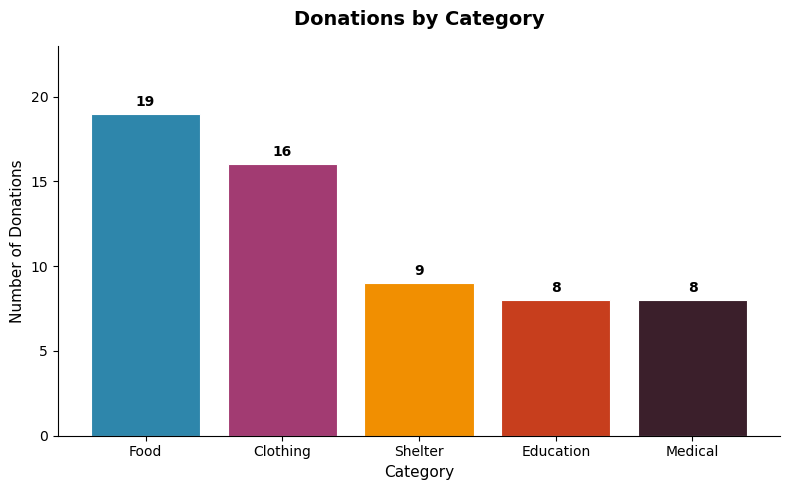

Insight: Shows which categories have the most available donations.


In [22]:
don_by_cat = df_donations["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
bars = ax.bar(don_by_cat.index, don_by_cat.values, color=colors, edgecolor="white", linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Donations by Category", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Category", fontsize=11)
ax.set_ylabel("Number of Donations", fontsize=11)
ax.set_ylim(0, don_by_cat.max() + 4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("donations_by_category.png", dpi=150)
plt.show()
print("Insight: Shows which categories have the most available donations.")


### 5.2 Aid Requests by Category

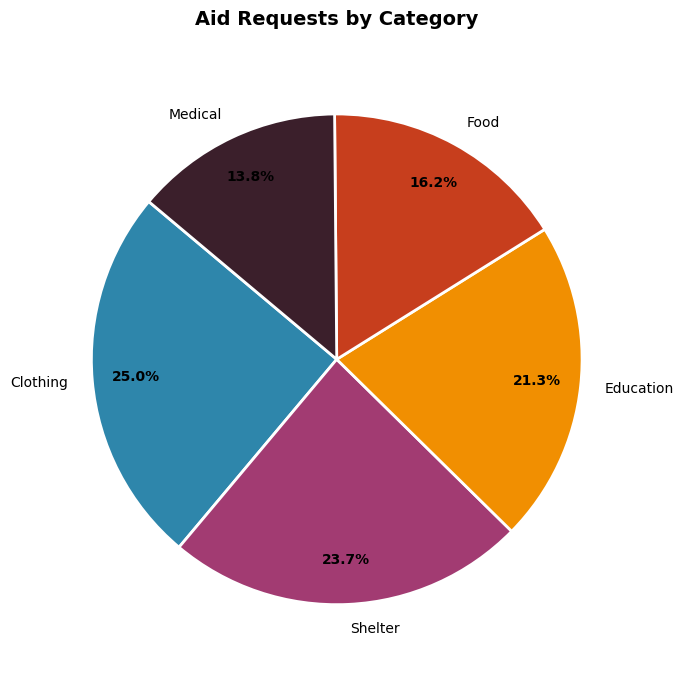

Insight: Reveals which aid categories are most in demand from receivers.


In [25]:
req_by_cat = df_requests["category"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedge_colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B"]
wedges, texts, autotexts = ax.pie(
    req_by_cat.values,
    labels=req_by_cat.index,
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight("bold")

ax.set_title("Aid Requests by Category", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("requests_by_category.png", dpi=150)
plt.show()
print("Insight: Reveals which aid categories are most in demand from receivers.")


### 5.3 Supply vs Demand Gap Analysis

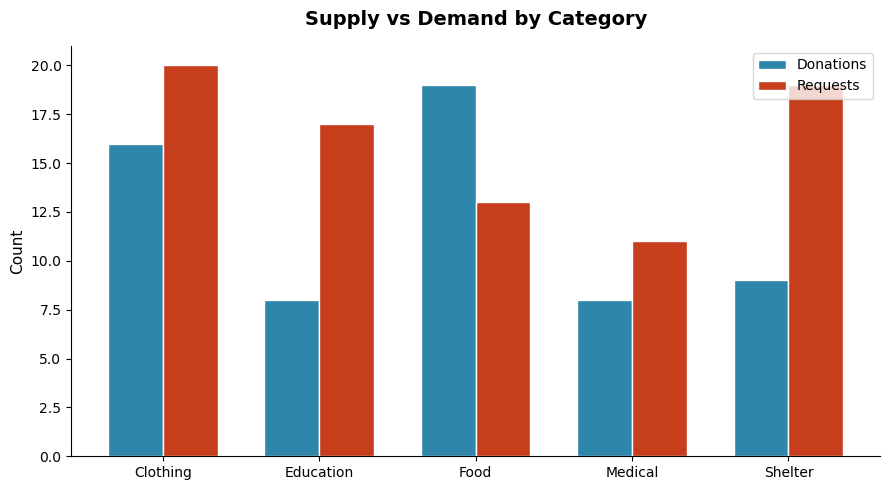


=== Supply vs Demand Gap ===
           Donations  Requests  Gap (Requests - Donations)
category                                                  
Clothing          16        20                           4
Education          8        17                           9
Food              19        13                          -6
Medical            8        11                           3
Shelter            9        19                          10

Insight: Positive gap = more requests than donations (unmet need).
Negative gap = surplus donations available in that category.


In [30]:
gap_df = pd.DataFrame({
    "Donations": don_by_cat,
    "Requests":  req_by_cat
}).fillna(0)

x     = range(len(gap_df))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar([i - width/2 for i in x], gap_df["Donations"],
       width, label="Donations", color="#2E86AB", edgecolor="white")
ax.bar([i + width/2 for i in x], gap_df["Requests"],
       width, label="Requests",  color="#C73E1D", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(gap_df.index, fontsize=10)
ax.set_title("Supply vs Demand by Category", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("supply_vs_demand.png", dpi=150)
plt.show()

gap_df["Gap (Requests - Donations)"] = gap_df["Requests"] - gap_df["Donations"]
print("\n=== Supply vs Demand Gap ===")
print(gap_df.to_string())
print("\nInsight: Positive gap = more requests than donations (unmet need).")
print("Negative gap = surplus donations available in that category.")


### 5.4 Urgency Distribution

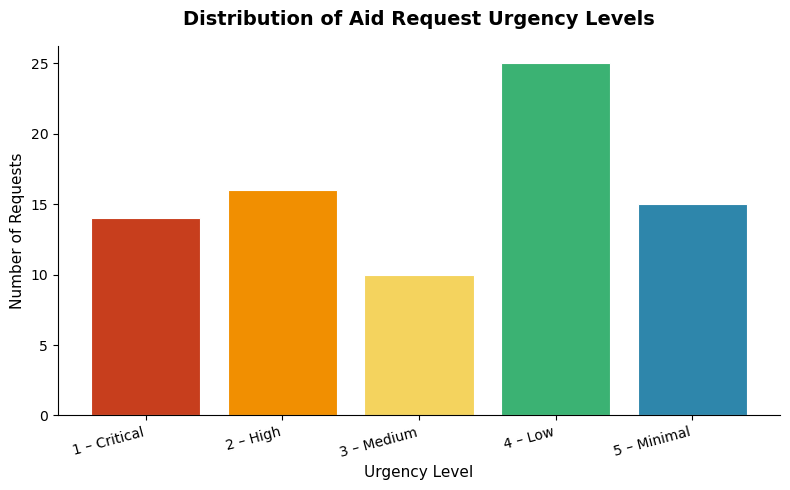

Insight: 30 requests (37.5%) are Critical or High urgency.
→ These are prioritised first by the matching algorithm.


In [33]:
urgency_counts = df_requests["urgency"].value_counts().sort_index()
urgency_labels = {1: "1 – Critical", 2: "2 – High", 3: "3 – Medium",
                  4: "4 – Low",      5: "5 – Minimal"}
urgency_colors = ["#C73E1D", "#F18F01", "#F4D35E", "#3BB273", "#2E86AB"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    [urgency_labels[i] for i in urgency_counts.index],
    urgency_counts.values,
    color=urgency_colors, edgecolor="white", linewidth=0.8
)
ax.set_title("Distribution of Aid Request Urgency Levels", fontsize=14,
             fontweight="bold", pad=15)
ax.set_xlabel("Urgency Level", fontsize=11)
ax.set_ylabel("Number of Requests", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("urgency_distribution.png", dpi=150)
plt.show()

critical = urgency_counts.get(1, 0) + urgency_counts.get(2, 0)
pct = round(critical / len(df_requests) * 100, 1)
print(f"Insight: {critical} requests ({pct}%) are Critical or High urgency.")
print("→ These are prioritised first by the matching algorithm.")


### 5.5 Requests vs Donations by Location

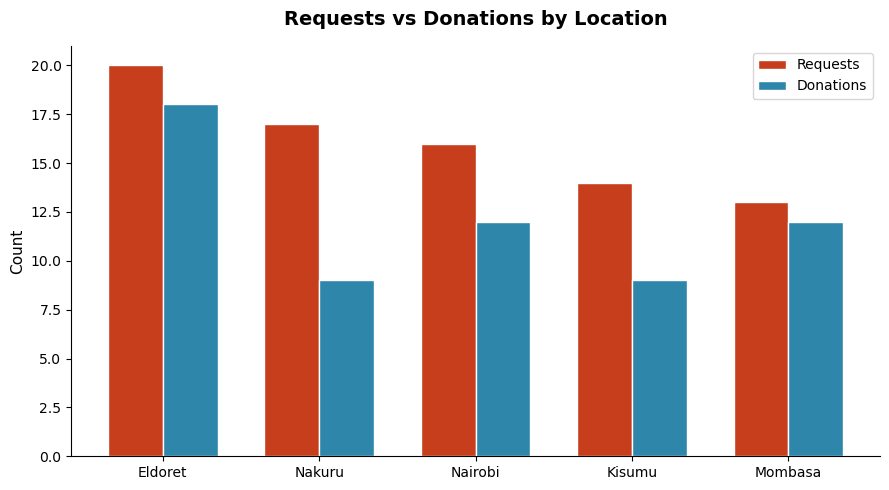

Insight: 'Eldoret' has the highest number of aid requests.
Location-aware matching ensures donors reach nearby receivers efficiently.


In [36]:
loc_req = df_requests["location"].value_counts()
loc_don = df_donations["location"].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
x     = range(len(loc_req))
width = 0.35

ax.bar([i - width/2 for i in x], loc_req.values, width,
       label="Requests",  color="#C73E1D", edgecolor="white")
ax.bar([i + width/2 for i in x],
       [loc_don.get(loc, 0) for loc in loc_req.index], width,
       label="Donations", color="#2E86AB", edgecolor="white")

ax.set_xticks(list(x))
ax.set_xticklabels(loc_req.index, fontsize=10)
ax.set_title("Requests vs Donations by Location", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Count", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("location_analysis.png", dpi=150)
plt.show()

top_loc = loc_req.idxmax()
print(f"Insight: '{top_loc}' has the highest number of aid requests.")
print("Location-aware matching ensures donors reach nearby receivers efficiently.")


### 5.6 System Match Rate

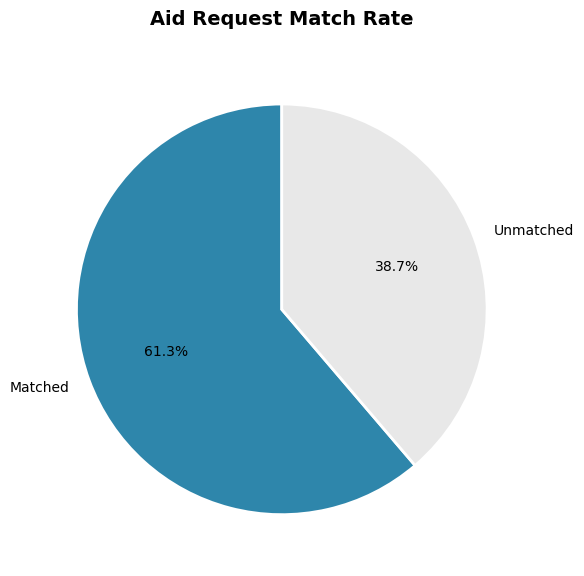

Matched Requests   : 49
Unmatched Requests : 31
Overall Match Rate : 61.3%

Insight: Unmatched requests highlight categories/locations where
more donations are needed to close the gap.


In [39]:
matched_count   = 0
unmatched_count = 0
used_donations  = set()

sorted_requests = df_requests.sort_values("urgency")

for _, req in sorted_requests.iterrows():
    matched = False
    for i, don in df_donations.iterrows():
        if i in used_donations:
            continue
        if req["category"] == don["category"] and req["location"] == don["location"]:
            matched_count += 1
            used_donations.add(i)
            matched = True
            break
    if not matched:
        unmatched_count += 1

match_rate = round(matched_count / len(df_requests) * 100, 1)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [matched_count, unmatched_count],
    labels=["Matched", "Unmatched"],
    autopct="%1.1f%%",
    colors=["#2E86AB", "#E8E8E8"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
ax.set_title("Aid Request Match Rate", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("match_rate.png", dpi=150)
plt.show()

print(f"Matched Requests   : {matched_count}")
print(f"Unmatched Requests : {unmatched_count}")
print(f"Overall Match Rate : {match_rate}%")
print(f"\nInsight: Unmatched requests highlight categories/locations where")
print("more donations are needed to close the gap.")


### 5.7 Key Findings Summary

In [42]:
most_donated = don_by_cat.idxmax()
most_needed  = req_by_cat.idxmax()
biggest_gap  = gap_df["Gap (Requests - Donations)"].idxmax()
top_location = loc_req.idxmax()

print("=" * 55)
print("       SMART AID FINDER — KEY FINDINGS SUMMARY")
print("=" * 55)
print(f"\n  Most donated category  : {most_donated}")
print(f"  Most requested category: {most_needed}")
print(f"  Biggest supply gap     : {biggest_gap}")
print(f"  Highest demand location: {top_location}")
print(f"  System match rate      : {match_rate}%")
print(f"  Critical/High urgency  : {pct}% of all requests")
print("\n  These insights can guide donation campaigns and")
print("  resource allocation to maximise aid impact.")
print("=" * 55)


       SMART AID FINDER — KEY FINDINGS SUMMARY

  Most donated category  : Food
  Most requested category: Clothing
  Biggest supply gap     : Shelter
  Highest demand location: Eldoret
  System match rate      : 61.3%
  Critical/High urgency  : 37.5% of all requests

  These insights can guide donation campaigns and
  resource allocation to maximise aid impact.
